In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

file_path = '../../data/finalProject/UCI_Credit_Card.csv'

df = pd.read_csv(file_path)

In [ ]:
df.info()
df.describe().T

In [15]:
# Drop ID since it is not useful
df.drop(columns=['ID'])

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,1,3,1,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,1,3,2,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,1,2,2,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,1,3,1,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


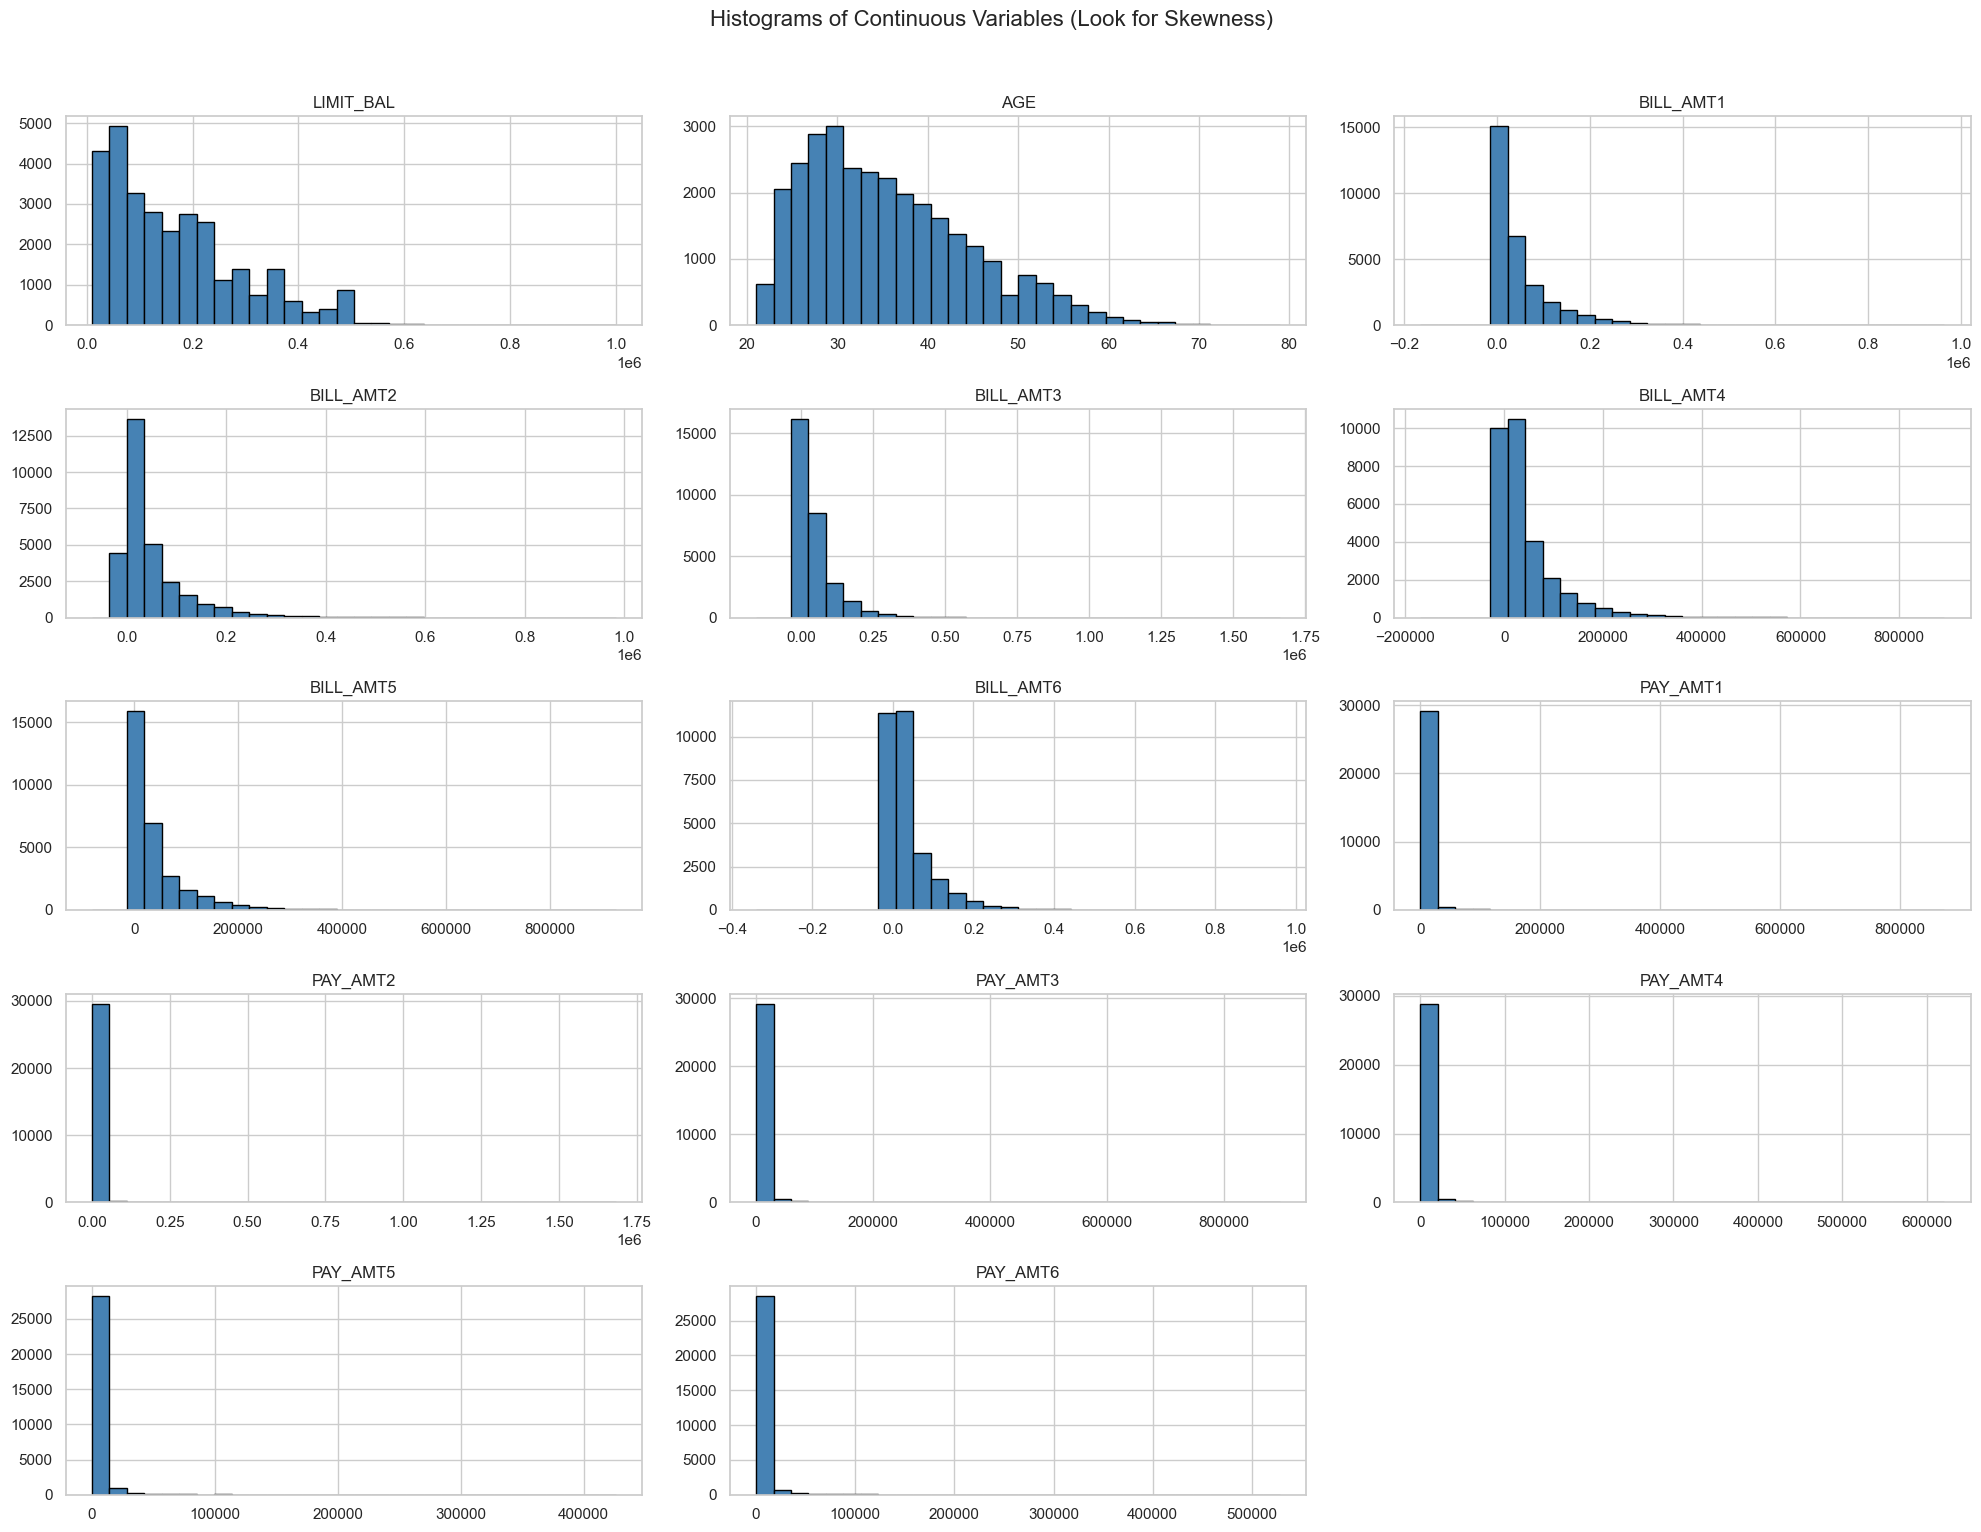

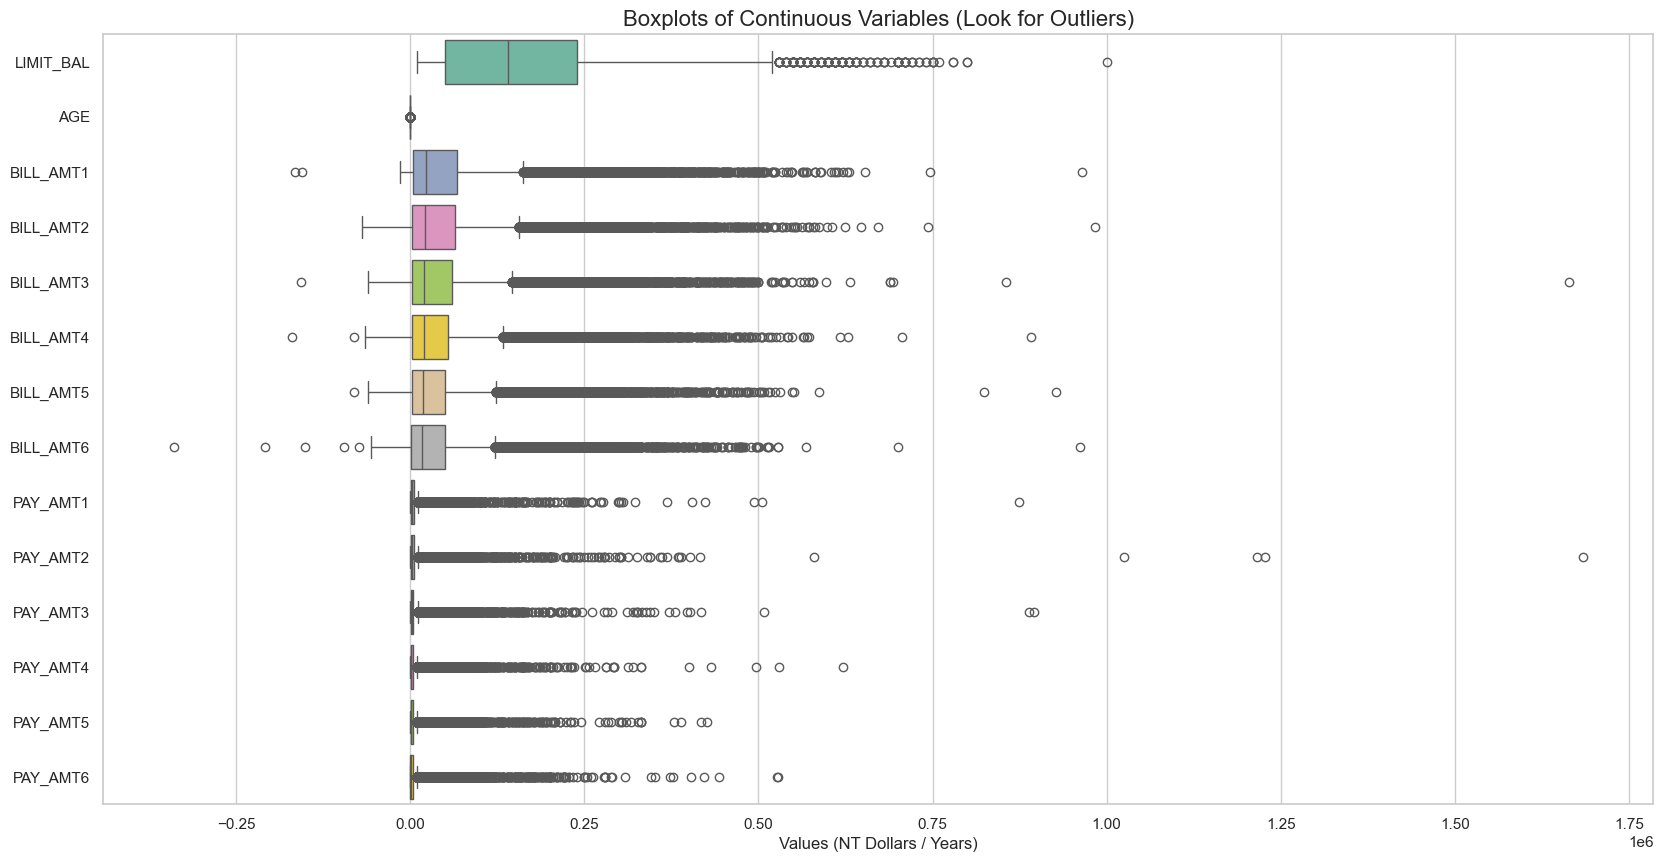

In [16]:
# Define continuous financial variables and age
continuous_vars = ['LIMIT_BAL', 'AGE'] + \
                  [f'BILL_AMT{i}' for i in range(1, 7)] + \
                  [f'PAY_AMT{i}' for i in range(1, 7)]

# Plot Histograms for distribution
df[continuous_vars].hist(bins=30, figsize=(20, 15), layout=(5, 3), color='steelblue', edgecolor='black')
plt.suptitle('Histograms of Continuous Variables (Look for Skewness)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Plot Boxplots to explicitly look for outliers
plt.figure(figsize=(20, 10))
# Standardizing the data temporarily just for visual comparison on the same scale
sns.boxplot(data=df[continuous_vars], orient="h", palette="Set2")
plt.title('Boxplots of Continuous Variables (Look for Outliers)', fontsize=16)
plt.xlabel('Values (NT Dollars / Years)')
plt.show()

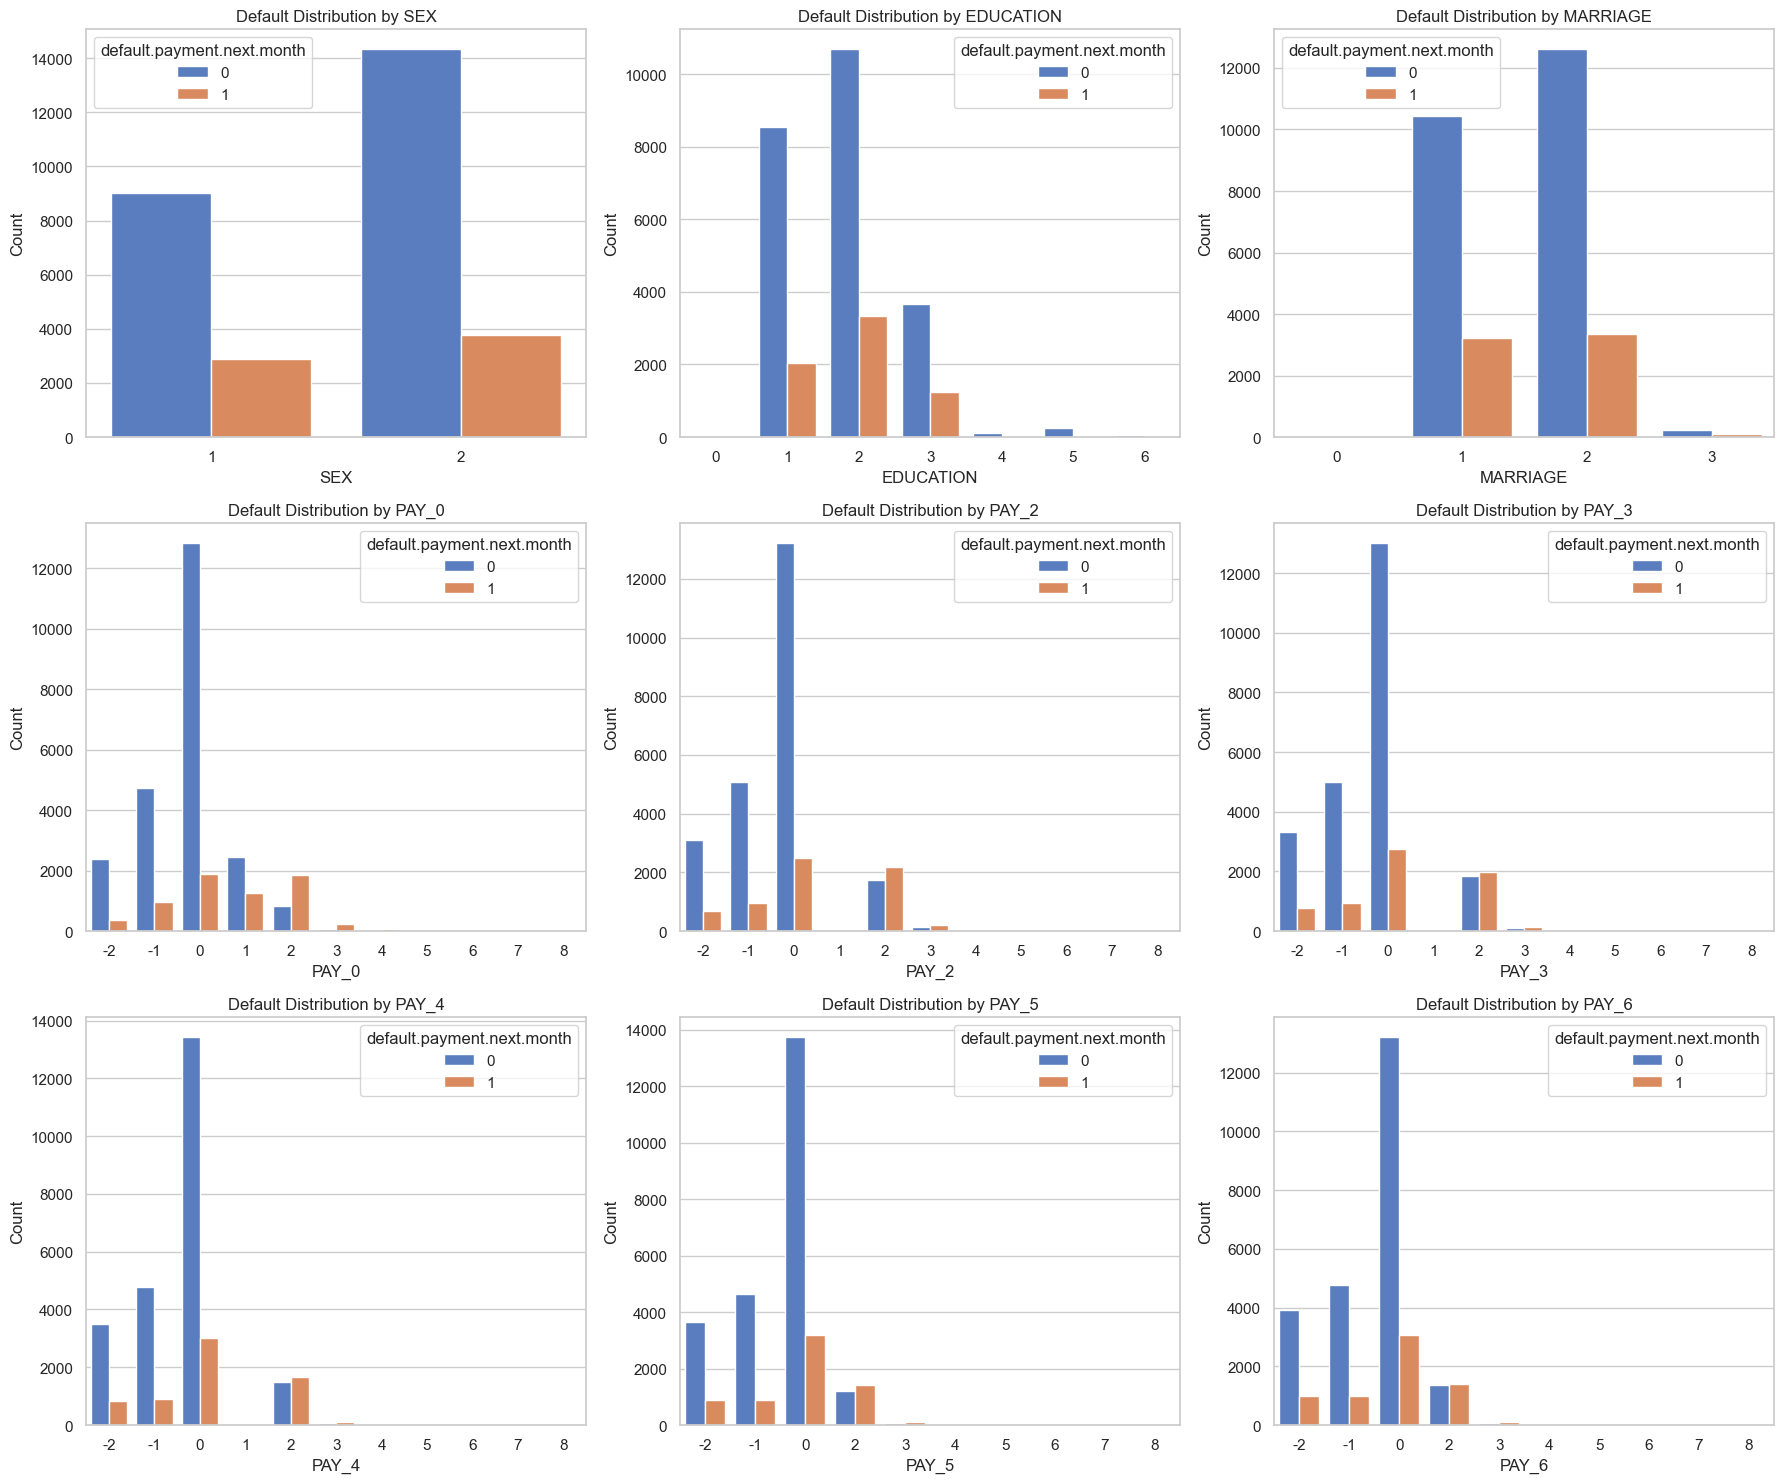

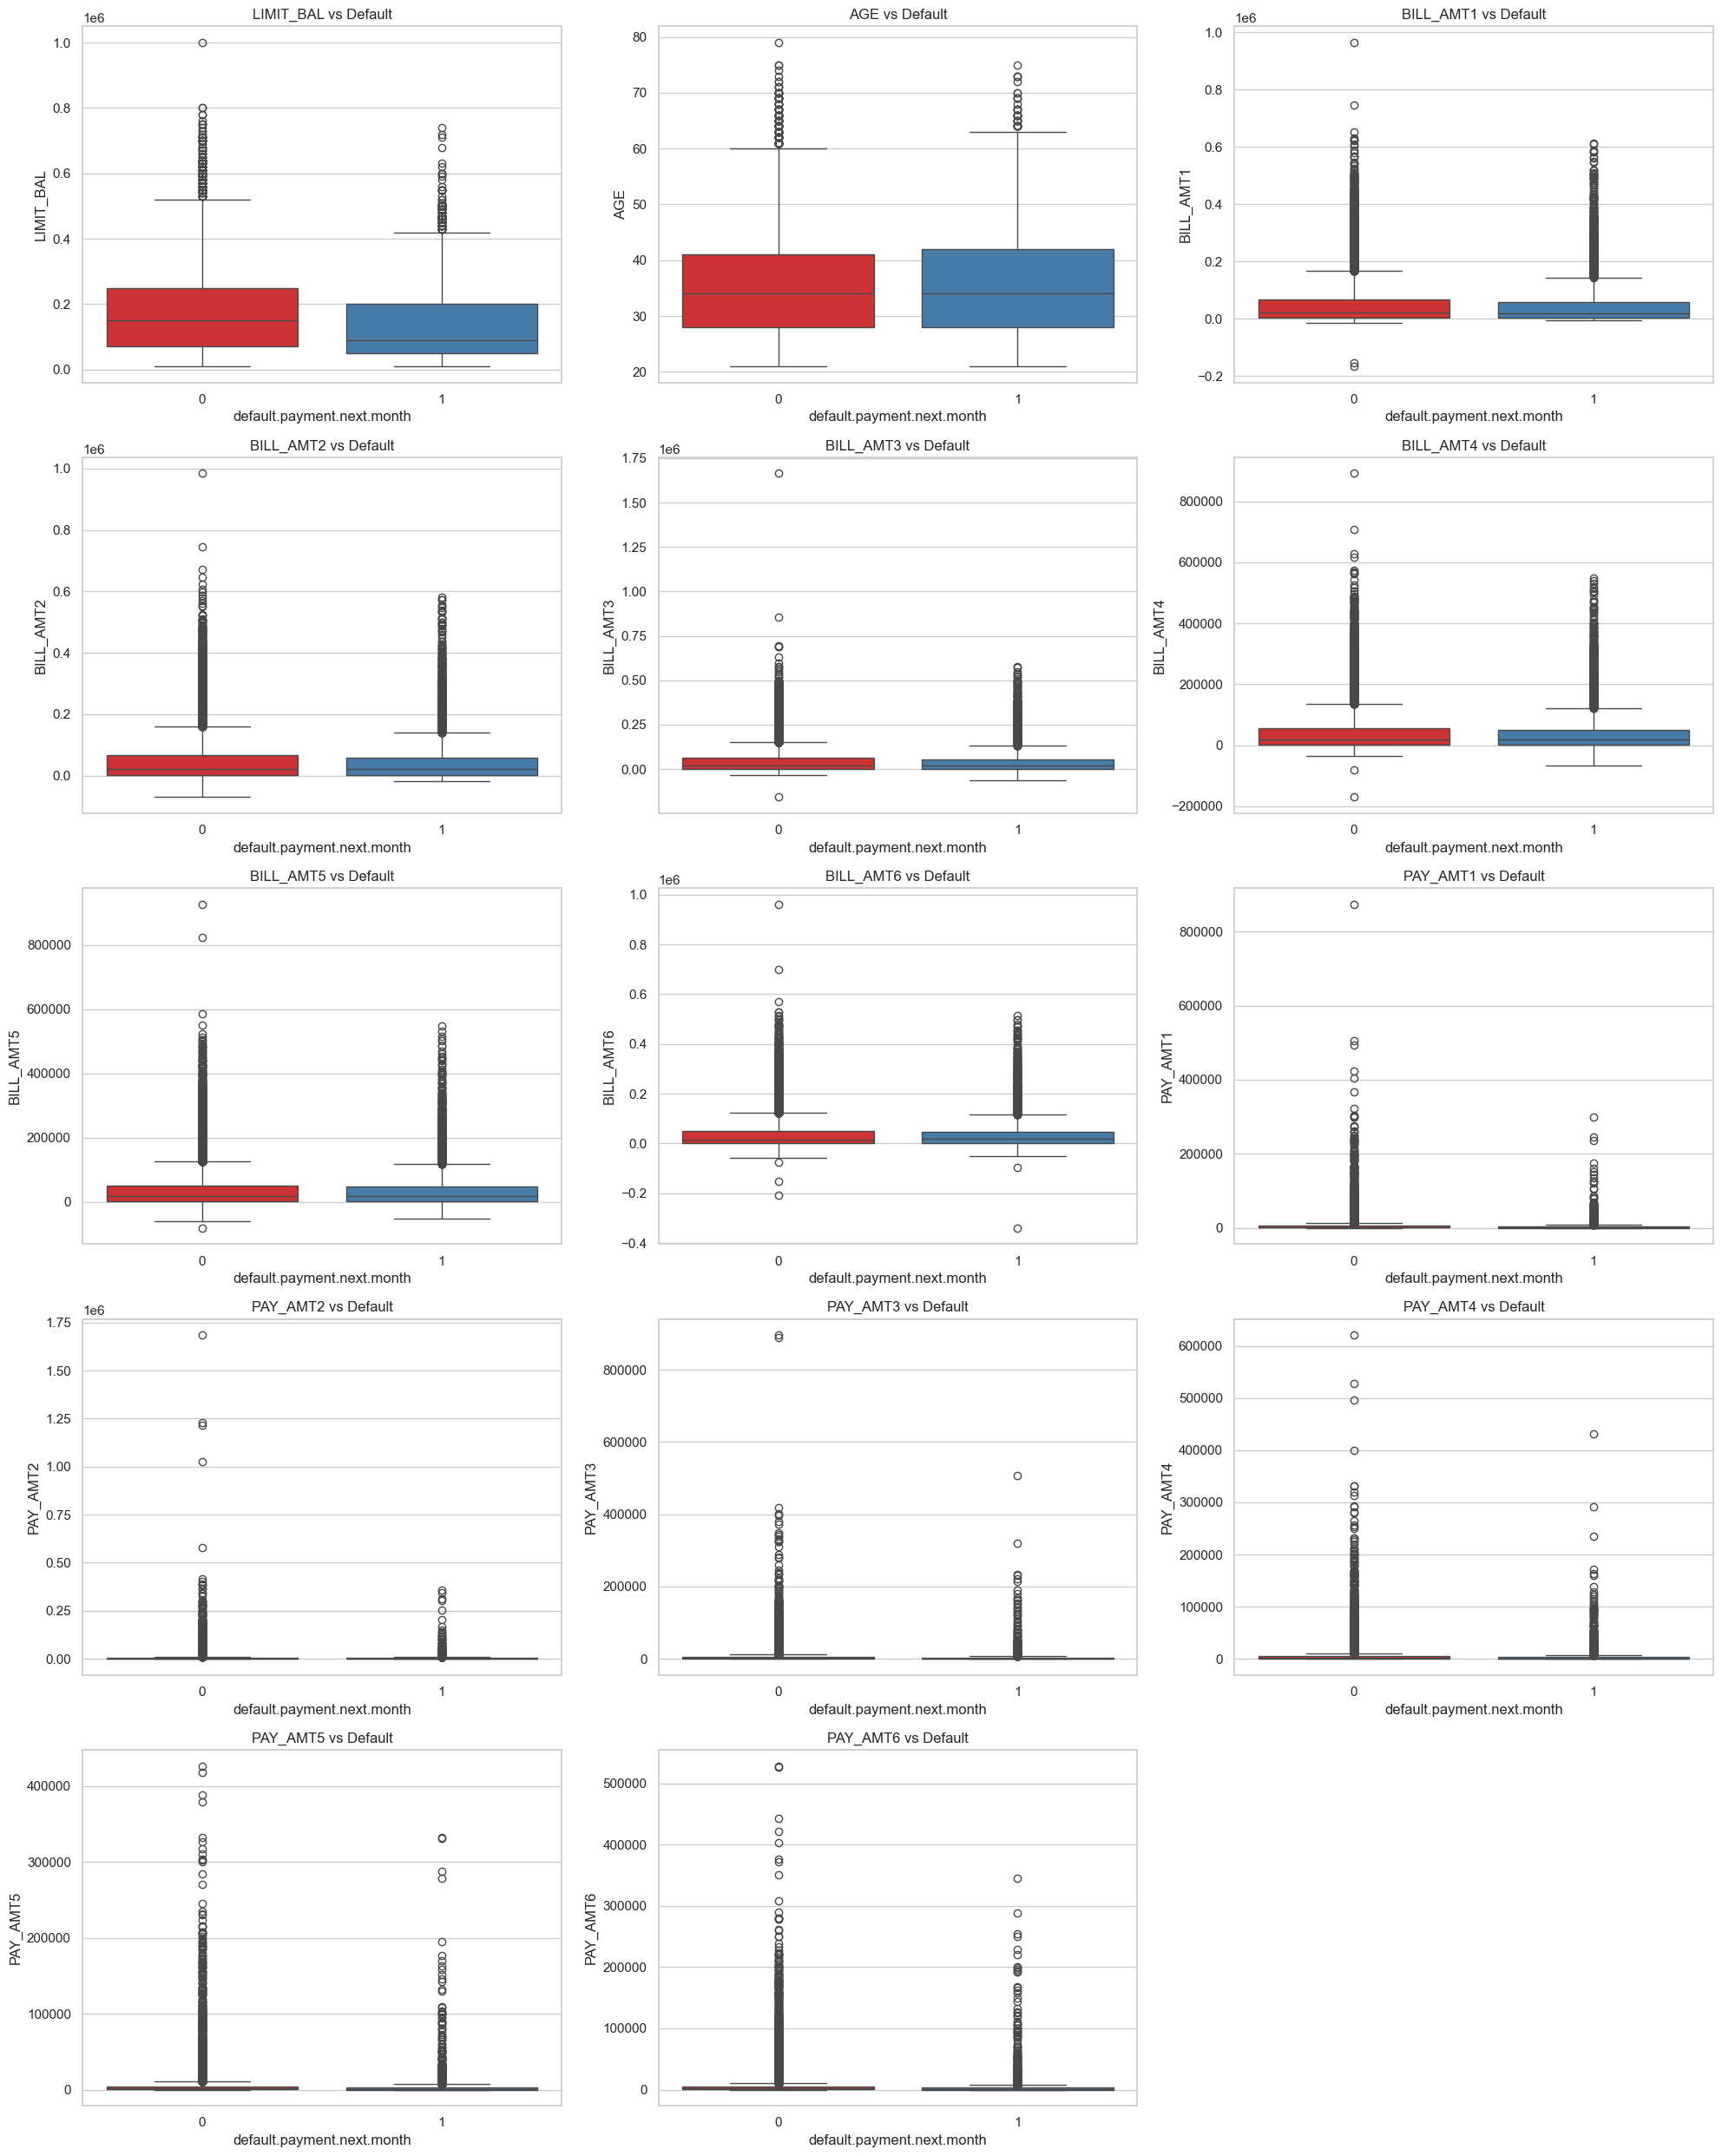

In [17]:
target = 'default.payment.next.month'

# Categorical & Ordinal Variables
categorical_vars = ['SEX', 'EDUCATION', 'MARRIAGE'] + [f'PAY_{i}' for i in [0, 2, 3, 4, 5, 6]]

# Plot Categorical against Target
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(categorical_vars):
    # Using a countplot with the target variable as the hue to see default rates per category
    sns.countplot(data=df, x=col, hue=target, ax=axes[i], palette='muted')
    axes[i].set_title(f'Default Distribution by {col}')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Plot Continuous against Target (using Boxplots to see if medians/distributions differ)
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(20, 25))
axes = axes.flatten()

for i, col in enumerate(continuous_vars):
    sns.boxplot(data=df, x=target, y=col, ax=axes[i], palette='Set1', hue=target, legend=False)
    axes[i].set_title(f'{col} vs Default')

# Remove the empty 15th subplot (since there are 14 continuous vars)
fig.delaxes(axes[-1]) 
plt.tight_layout()
plt.show()

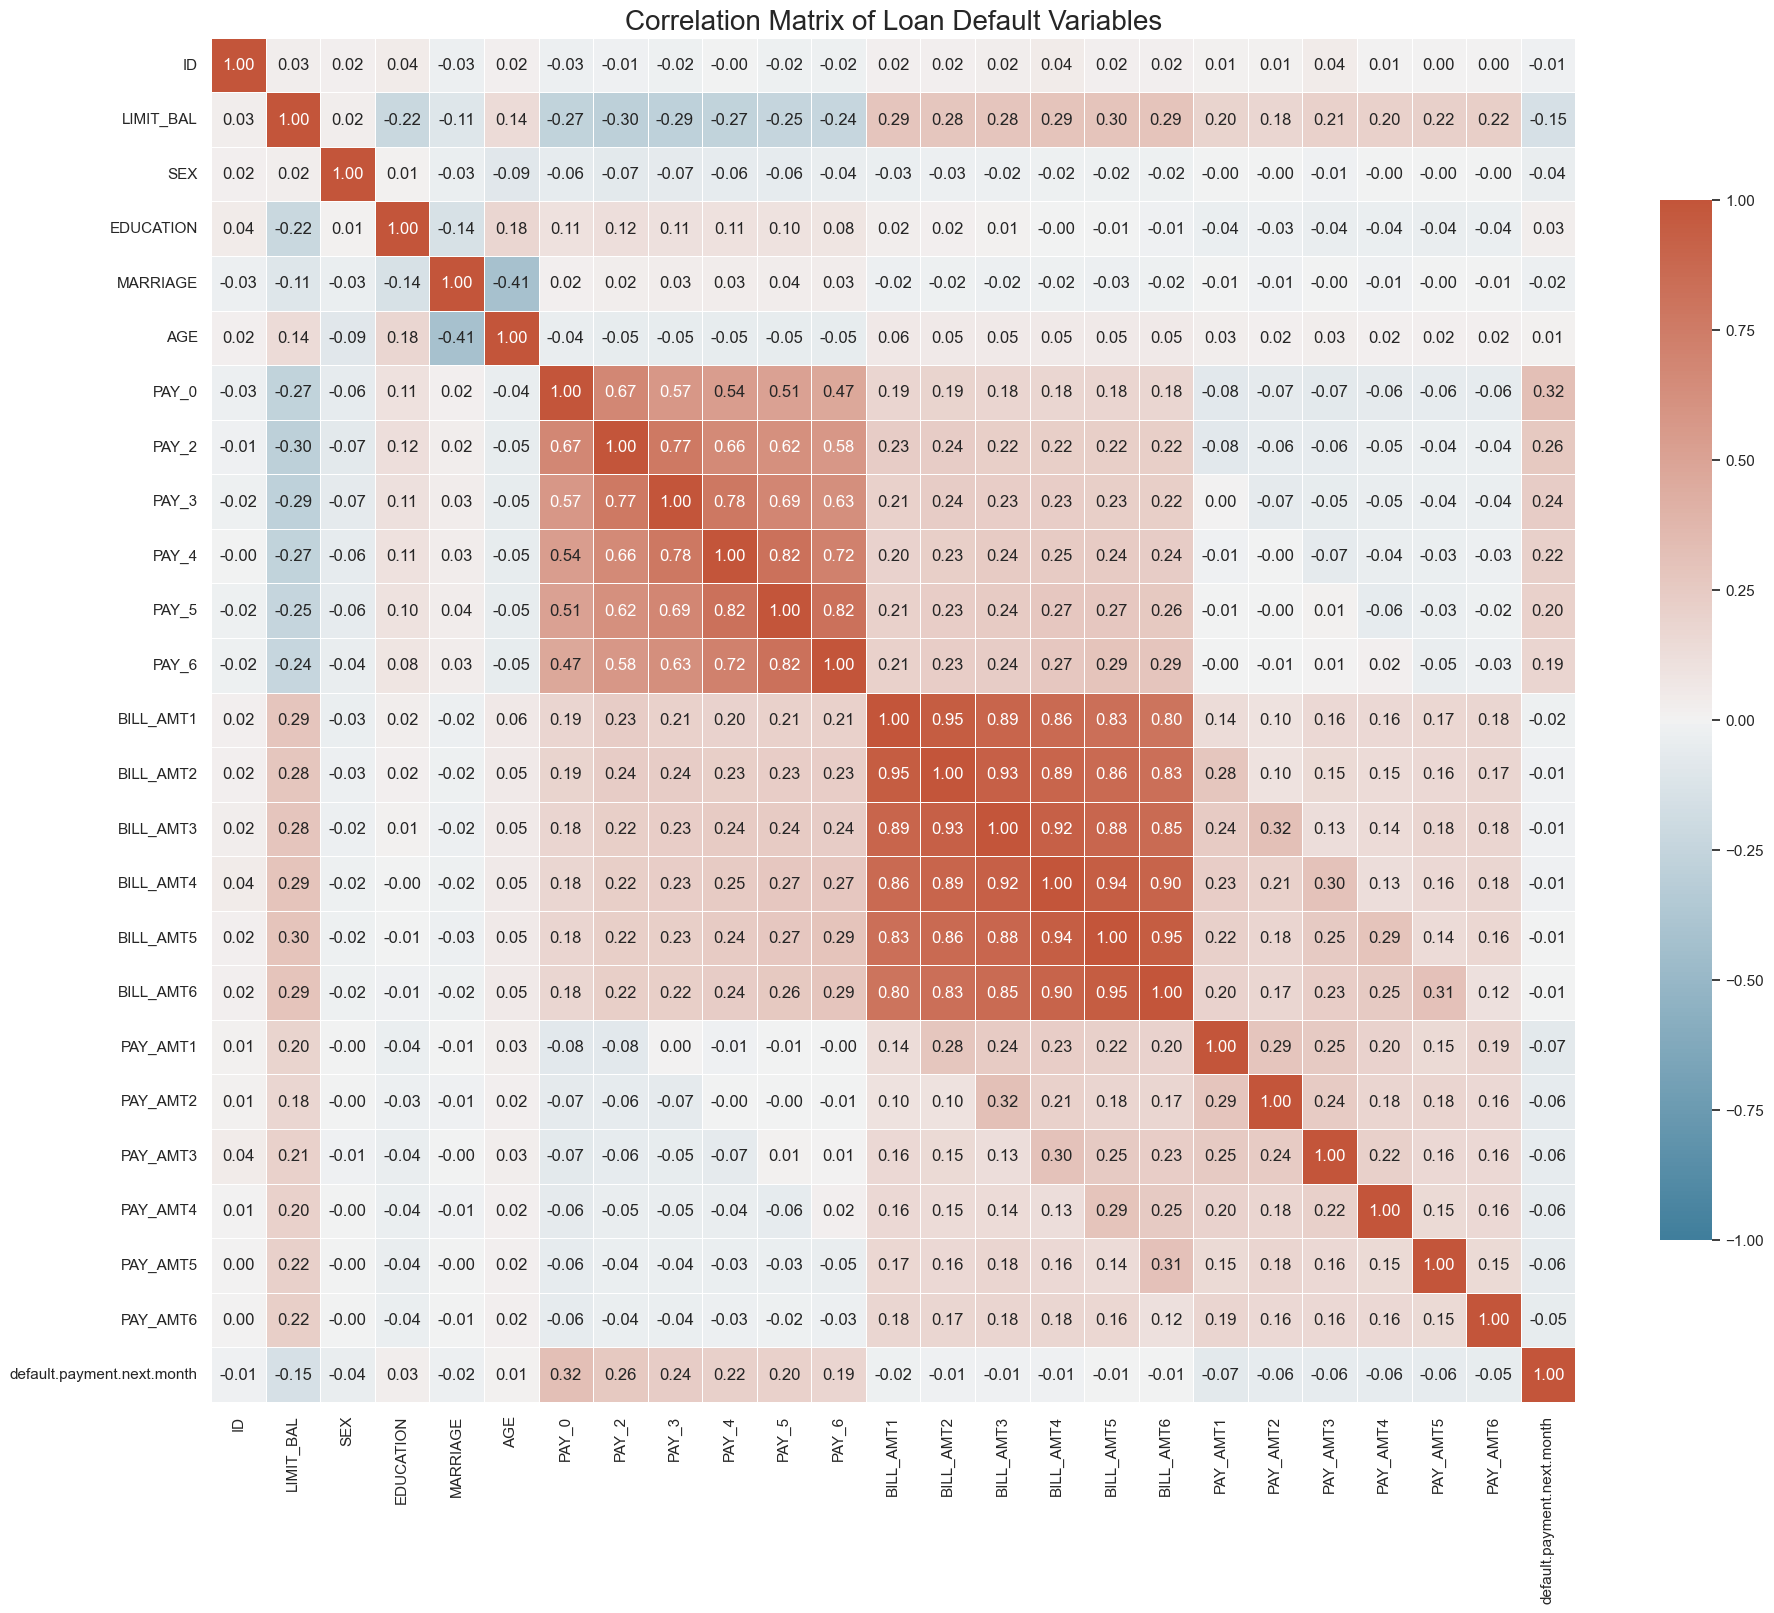


--- Correlation with Target Variable ---


default.payment.next.month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
EDUCATION                     0.028006
AGE                           0.013890
BILL_AMT6                    -0.005372
BILL_AMT5                    -0.006760
BILL_AMT4                    -0.010156
ID                           -0.013952
BILL_AMT3                    -0.014076
BILL_AMT2                    -0.014193
BILL_AMT1                    -0.019644
MARRIAGE                     -0.024339
SEX                          -0.039961
PAY_AMT6                     -0.053183
PAY_AMT5                     -0.055124
PAY_AMT3                     -0.056250
PAY_AMT4                     -0.056827
PAY_AMT2                     -0.058579
PAY_AMT1                     -0.072929
LIMIT_BAL                    -0.153520
Name: default.payment.nex

In [18]:
# Compute the correlation matrix
corr_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(22, 18))

# Generate a custom diverging colormap for better readability
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_matrix, 
            cmap=cmap, 
            vmax=1.0, 
            vmin=-1.0, 
            center=0,
            annot=True,       # Shows the correlation values
            fmt='.2f',        # Formats the values to 2 decimal places
            square=True, 
            linewidths=.5, 
            cbar_kws={"shrink": .75})

plt.title('Correlation Matrix of Loan Default Variables', fontsize=20)
plt.show()

# Focus specifically on correlations with the target variable
print("\n--- Correlation with Target Variable ---")
target_corr = corr_matrix[target].sort_values(ascending=False)
display(target_corr)